Method A: mean = 67.08, SD = 3.60
Method B: mean = 75.83, SD = 3.33
Degrees of freedom = 22
t statistic = -6.1804
t critical  = ±2.0739
p-value     = 0.000003

Decision: Reject H0 -> The two teaching methods give significantly different marks.


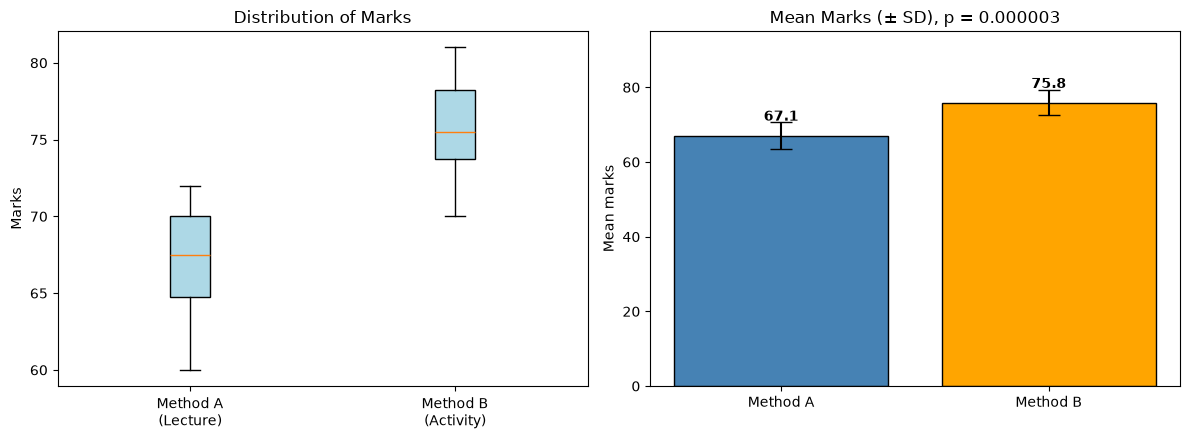

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Step 1: Data - marks of two different groups of students
method_A = np.array([
    65, 70, 68, 72, 60, 66,
    69, 71, 64, 67, 63, 70
])   # Lecture

method_B = np.array([
    72, 78, 75, 80, 74, 77,
    79, 73, 76, 81, 70, 75
])   # Activity-based

alpha = 0.05

# Step 2: Independent two-sample t-test
# Equal variances assumed
t_stat, p_value = stats.ttest_ind(
    method_A,
    method_B,
    equal_var=True
)

df = len(method_A) + len(method_B) - 2

t_critical = stats.t.ppf(
    1 - alpha / 2,
    df
)

print(
    f"Method A: mean = {method_A.mean():.2f}, "
    f"SD = {method_A.std(ddof=1):.2f}"
)

print(
    f"Method B: mean = {method_B.mean():.2f}, "
    f"SD = {method_B.std(ddof=1):.2f}"
)

print(f"Degrees of freedom = {df}")
print(f"t statistic = {t_stat:.4f}")
print(f"t critical  = ±{t_critical:.4f}")
print(f"p-value     = {p_value:.6f}")

# Step 3: Decision
if p_value < alpha:
    print(
        "\nDecision: Reject H0 -> "
        "The two teaching methods give significantly different marks."
    )
else:
    print(
        "\nDecision: Fail to reject H0 -> "
        "No significant difference between the methods."
    )

# Step 4: Graphs
# Boxplot and mean bar chart

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# -------------------------
# Graph 1: Boxplot
# -------------------------

ax[0].boxplot(
    [method_A, method_B],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue')
)

ax[0].set_xticks([1, 2])

ax[0].set_xticklabels([
    'Method A\n(Lecture)',
    'Method B\n(Activity)'
])

ax[0].set_title('Distribution of Marks')
ax[0].set_ylabel('Marks')

# -------------------------
# Graph 2: Mean bar chart
# -------------------------

means = [
    method_A.mean(),
    method_B.mean()
]

errors = [
    method_A.std(ddof=1),
    method_B.std(ddof=1)
]

ax[1].bar(
    ['Method A', 'Method B'],
    means,
    yerr=errors,
    capsize=8,
    color=['steelblue', 'orange'],
    edgecolor='black'
)

for i, m in enumerate(means):
    ax[1].text(
        i,
        m + 4,
        f'{m:.1f}',
        ha='center',
        fontweight='bold'
    )

ax[1].set_title(
    f'Mean Marks (± SD), p = {p_value:.6f}'
)

ax[1].set_ylabel('Mean marks')
ax[1].set_ylim(0, 95)

plt.tight_layout()
plt.show()